# 04 · Lab NMR data: what we have

NMR data from experiments (2022–2023), read straight from the instrument files. A first, descriptive look: no fitting, no peak assignment beyond the obvious.

**How to read a spectrum.** Each species gives a peak at its own position (ppm, horizontal axis). If a peak appears, grows or disappears, that species is forming or being consumed. Peak height or area (vertical axis) says roughly how much of it there is.

**Species that appear below**

| Name | What it is |
|---|---|
| TMSPA → BMSPA → MMSPA → H₃PO₄ | the phosphate additive losing its TMS (trimethylsilyl) groups one at a time: 3, 2, 1, 0 left |
| TMSOH | trimethylsilanol, a TMS group on an OH |
| TMSOTMS (HMDSO) | two TMS groups joined through one oxygen |
| TMS-EG | a TMS group on ethylene glycol, from the ring-opening of EC |
| EC, DEC | the solvents (ethylene carbonate, diethyl carbonate) |

**Questions this notebook answers**
1. Which samples were measured, when, and with which nuclei? (§1–2)
2. What do the spectra look like, and does anything change in time? (§3–4)
3. What is wrong or unclear in the files? (§5)

**Limits of this first pass**
- **Shifts are as acquired.** The ppm axis is the spectrometer's own, not tied to a reference peak, so a whole spectrum can be displaced by a small constant. Compare positions only within one spectrum or one campaign. The Gogoi 2024 shifts drawn as dashed lines are for orientation only. Referencing is the next step.
- **Raw signals are converted and phased automatically** (`kinetics/data/lab_nmr.py`). Appendix A checks this against the spectrometer's own exports, for one sample only.
- **Areas are rough:** sums over a ppm window above a local baseline, not fitted peaks.

**NMR data.** The spectra are read from the folder given by the environment variable `LAB_NMR_DIR` (see `.env.example`).

**Source:** Y. Alcaraz Galván; NMR data from experiments

In [1]:
%load_ext autoreload
%autoreload 2

import sys
from pathlib import Path

# Make the repository importable whether the notebook runs from notebooks/ or from the repository root
REPO = Path.cwd() if (Path.cwd() / 'kinetics').is_dir() else Path.cwd().parent
if str(REPO) not in sys.path:
    sys.path.insert(0, str(REPO))

import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

from kinetics import get_measured_shifts                  # shifts read from Gogoi 2024 (for orientation)
from kinetics.data import (
    DEFAULT_LAB_NMR_DIR,             # where the raw data are read from (the folder in LAB_NMR_DIR)
    build_lab_nmr_inventory,         # one row per .jdf file: acquisition metadata, no processing
    load_lab_sample_folders,         # names of the folders and files of the spectra
    calculate_window_integrals,      # area / height / position of the signal in named ppm windows
    estimate_noise,                  # noise level of a spectrum
    load_spectrum,                   # .jdf → (ppm, real spectrum); raw signals are transformed and phased
    load_text_spectrum,              # spectrometer text export (.txt / .asc) → (ppm, intensity)
)
from demo.style import apply_style
from demo.lab_nmr_plots import (
    plot_acquisition_timeline, plot_peak_ratio_series, plot_processing_check, plot_spectra_stack,
)

apply_style()
DATA_DIR = Path(DEFAULT_LAB_NMR_DIR)
print('raw data folder (LAB_NMR_DIR):', 'found' if DATA_DIR.is_dir() else 'NOT FOUND: set LAB_NMR_DIR')

raw data folder (LAB_NMR_DIR): found


## 1. What was measured

`build_lab_nmr_inventory` reads the header of every `.jdf` file (the instrument's format). The sample each folder holds is set by hand from the folder name; one folder holds two samples, and there the title stored in the file decides. Composition is in vol% in EC/DEC 1:1, as in Gogoi 2024.

In [2]:
_FOLDERS = load_lab_sample_folders()          # folder and title names of the spectra
SAMPLE_OF_FOLDER = _FOLDERS['sample_of_folder']
# The one folder with two samples: decided by the title stored in each file
SAMPLE_OF_TITLE = _FOLDERS['sample_of_title']
# What was done to each sample, read from the folder names and the dates in the table below
WHAT_WAS_DONE = {
    '5% TMSPa + 0.5% H2O':                   'room temperature, one day',
    '5% TMSPa + 2% H2O':                     'spectra at 30 → 80 °C in the probe, and at room temperature after each step',
    '5% TMSOH, heated in the probe':         'before heating, at 80 °C, and after',
    '5% TMSOH, stirred at 80 °C (glovebox)': 'stirred at 80 °C in a glovebox, one measurement',
    '5% TMSPa':                              'fresh, and again 10 days later',
    '5% TMSPa + 2% TMSOH (A)':               'fresh, and again 10–11 days later',
    '5% TMSPa + 2% TMSOH (B)':               'fresh only',
    '5% TMSOH + 2% H2O':                     'on 17–18 May, and again on 25 May',
    '5% TMSOTMS + 2% H2O':                   'on 18 May, and again on 25 May',
}

inventory = build_lab_nmr_inventory(DATA_DIR)
inventory['sample'] = inventory['title'].map(SAMPLE_OF_TITLE).fillna(inventory['folder'].map(SAMPLE_OF_FOLDER))
assert inventory['sample'].notna().all(), inventory.loc[inventory['sample'].isna(), 'folder'].unique()
inventory['campaign'] = inventory['acquired_at'].dt.year

n_exports = sum(1 for p in DATA_DIR.rglob('*') if p.is_file() and p.suffix.lower() in ('.txt', '.asc'))
print(f'{len(inventory)} spectra (.jdf files), plus {n_exports} text exports processed by the spectrometer')

samples = inventory.groupby('sample').agg(
    campaign=('campaign', 'first'), spectra=('file', 'size'),
    nuclei=('nucleus', lambda s: ', '.join(sorted(set(s)))),
    first=('acquired_at', lambda t: t.min().strftime('%d %b')), last=('acquired_at', lambda t: t.max().strftime('%d %b')),
).join(pd.Series(WHAT_WAS_DONE, name='what was done'))
display(samples.sort_values(['campaign', 'first']))

89 spectra (.jdf files), plus 7 text exports processed by the spectrometer


,campaign,spectra,nuclei,first,last,what was done
sample,,,,,,
"5% TMSOH, stirred at 80 °C (glovebox)",2022,5,"13C, 19F, 1H, 29Si, 31P",04 Oct,04 Oct,"stirred at 80 °C in a glovebox, one measurement"
5% TMSPa + 0.5% H2O,2022,4,"13C, 29Si, 31P",21 Apr,22 Apr,"room temperature, one day"
5% TMSPa + 2% H2O,2022,42,"13C, 1H, 29Si, 31P",22 Jun,28 Jun,"spectra at 30 → 80 °C in the probe, and at roo..."
"5% TMSOH, heated in the probe",2022,13,"13C, 1H, 29Si, 31P",30 Jun,06 Jul,"before heating, at 80 °C, and after"
5% TMSPa,2023,8,"1H, 29Si, 31P",15 May,25 May,"fresh, and again 10 days later"
5% TMSPa + 2% TMSOH (A),2023,7,"13C, 1H, 29Si, 31P",15 May,26 May,"fresh, and again 10–11 days later"
5% TMSOH + 2% H2O,2023,4,"1H, 29Si",17 May,25 May,"on 17–18 May, and again on 25 May"
5% TMSOTMS + 2% H2O,2023,3,"1H, 29Si",18 May,25 May,"on 18 May, and again on 25 May"
5% TMSPa + 2% TMSOH (B),2023,3,"1H, 29Si, 31P",29 May,29 May,fresh only


One row per sample, one marker per spectrum (colour and shape = nucleus). Hollow markers were recorded above 25 °C.

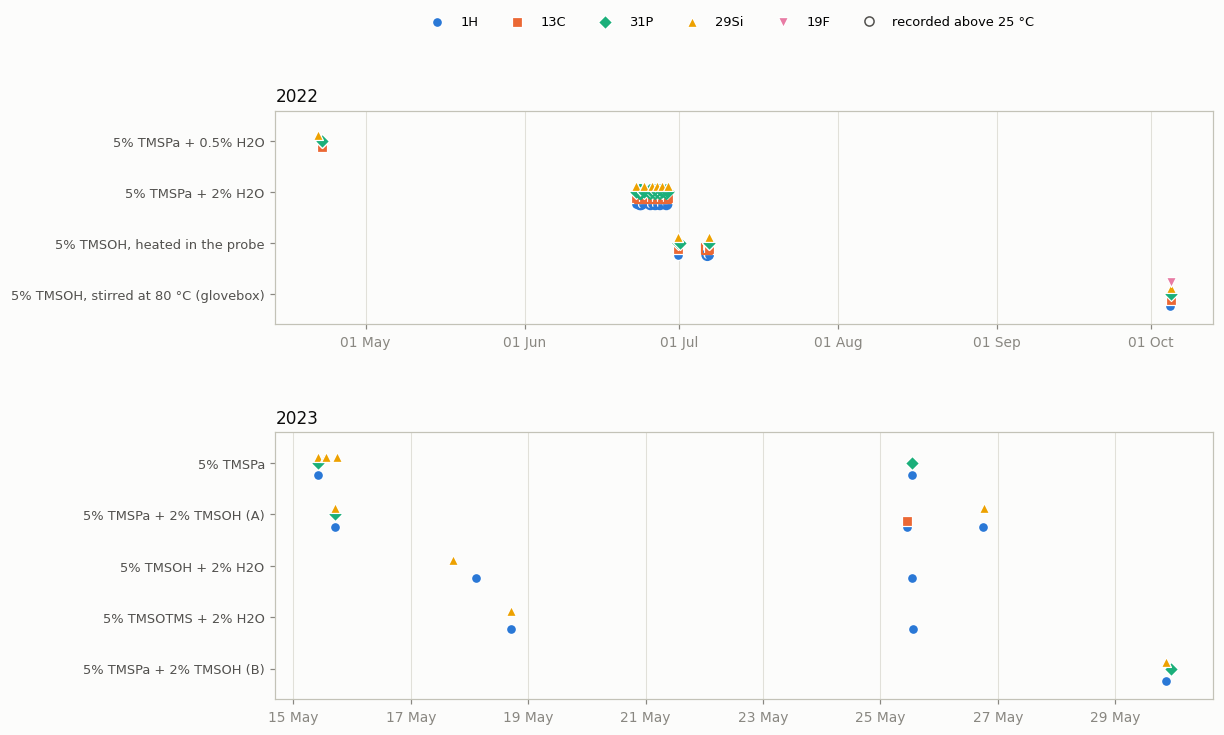

In [3]:
fig = plot_acquisition_timeline(inventory)
plt.show()

**Reading.** Nine samples in two campaigns.
- **2022** (4 samples): TMSPa with 0.5% and 2% water, and TMSOH alone. These look like the experiments behind Gogoi 2024 (Fig. 1a, S2 and 5).
- **2023** (5 samples): TMSPa alone, two TMSPa + TMSOH tubes, and TMSOH or TMSOTMS with water. Most were measured fresh and again 7–11 days later.
- The 2% water sample of 2022 is the only one with many spectra in a row (§4.1).

## 2. How the spectra were recorded

Whether a peak area can be read as an amount depends on how the spectrum was recorded. For ³¹P, ¹³C and ²⁹Si the proton decoupling can distort peak intensities (the "NOE") unless the acquisition suppresses it. Here each nucleus is summarised: how many spectra, how long one takes, and how many have the NOE switched off.

In [4]:
by_nucleus = inventory.groupby('nucleus').agg(
    spectra=('file', 'size'),
    minutes_per_spectrum=('duration_min', 'median'),
    noe_switched_off=('noe', lambda s: int((s == 'FALSE').sum())),
    recorded_above_25C=('temperature_C', lambda t: int((t > 25).sum())),
).round({'minutes_per_spectrum': 1})
display(by_nucleus.loc[[n for n in ['31P', '29Si', '13C', '1H', '19F'] if n in by_nucleus.index]])

,spectra,minutes_per_spectrum,noe_switched_off,recorded_above_25C
nucleus,,,,
31P,23,6.5,17,6
29Si,20,566.4,0,0
13C,18,3.5,0,7
1H,27,3.5,0,7
19F,1,1.8,0,0


**Reading.**
- **³¹P** is fast (seconds to minutes) and mostly has the NOE switched off. It is the one nucleus whose peak areas can be read as amounts, at least in the room-temperature spectra. The ones at temperature have the NOE on, so they are not comparable with the rest.
- **²⁹Si** takes about 9 hours per spectrum with direct acquisition, and only some of it shows signal. The faster 2023 spectra (INEPT) show which species are present, but not how much.
- **¹H** takes a few minutes and is the only nucleus with that time resolution, but its peaks need assigning (§A, B).
- A finer table by acquisition settings is in Appendix C.

## 3. What the spectra look like: ³¹P of every TMSPa sample

³¹P sees the phosphorus only, so one peak = one phosphate species. The figure shows the first and last room-temperature spectrum of each sample with TMSPa, each scaled to its own tallest peak. Dashed lines are the shifts read from Gogoi 2024 (orientation only; our axes are not referenced).

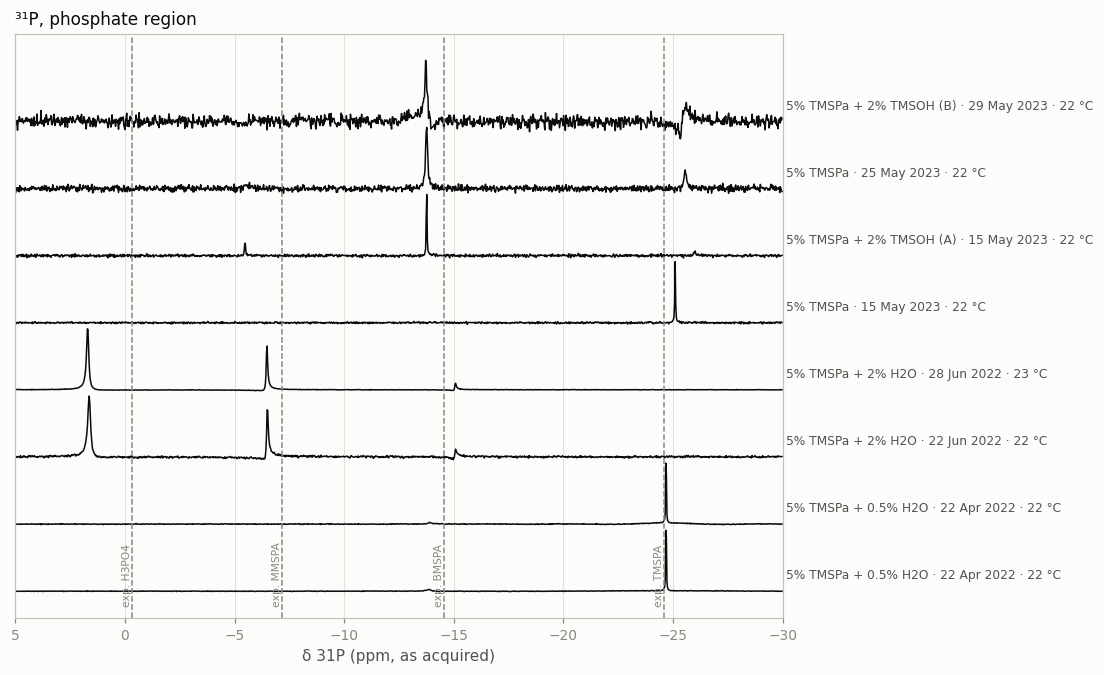

In [5]:
experimental = get_measured_shifts()
spectra = {}                                      # cache: (path, window) → (ppm, intensity)

def spectrum(row, window_ppm):
    # Phase refined for the window that is shown or integrated
    key = (row['path'], tuple(window_ppm))
    if key not in spectra:
        spectra[key] = load_spectrum(row['path'], window_ppm=window_ppm)
    return spectra[key]

def label(row):
    return f"{row['sample']} · {row['acquired_at']:%d %b %Y} · {row['temperature_C']:.0f} °C"

p31 = inventory[(inventory['nucleus'] == '31P') & inventory['sample'].str.contains('TMSPa')
                & (inventory['temperature_C'] < 25)]
picked = pd.concat([p31.groupby('sample').head(1), p31.groupby('sample').tail(1)]).drop_duplicates('path')
picked = picked.sort_values('acquired_at')
plot_spectra_stack([(label(r), *spectrum(r, (-30, 5))) for _, r in picked.iterrows()], window_ppm=(-30, 5),
                   nucleus='31P', experimental=experimental, title='³¹P, phosphate region')
plt.show()

**Reading.** From left to right the peaks are: H₃PO₄ (≈ +1.6), MMSPA (≈ −6.5), BMSPA (−13.7 to −15.1) and TMSPA (≈ −25).
- **0.5% water:** mostly TMSPA, with a trace of BMSPA.
- **2% water (2022):** no TMSPA left; mostly H₃PO₄ and MMSPA.
- **TMSPa alone, 2023:** TMSPA on 15 May, mostly BMSPA ten days later (§4.2).
- **TMSPa + TMSOH, 2023:** no TMSPA in the first spectrum of tube A; BMSPA dominates.
- **Offsets:** TMSPA sits at −24.7 in 2022 and at −25.1 in 2023, and our H₃PO₄ is 2 ppm from the Gogoi value (−0.33). This is why the axes need referencing before peaks are matched across campaigns.

## 4. Is anything changing in time?

### 4.1 Heating ramp, TMSPa + 2% water (22–28 June 2022)

The sample was heated in the spectrometer to 30, 40, … 80 °C. Spectra were taken at each temperature and again at room temperature after each step (light → dark = time). All ³¹P spectra of the sample, in time order:

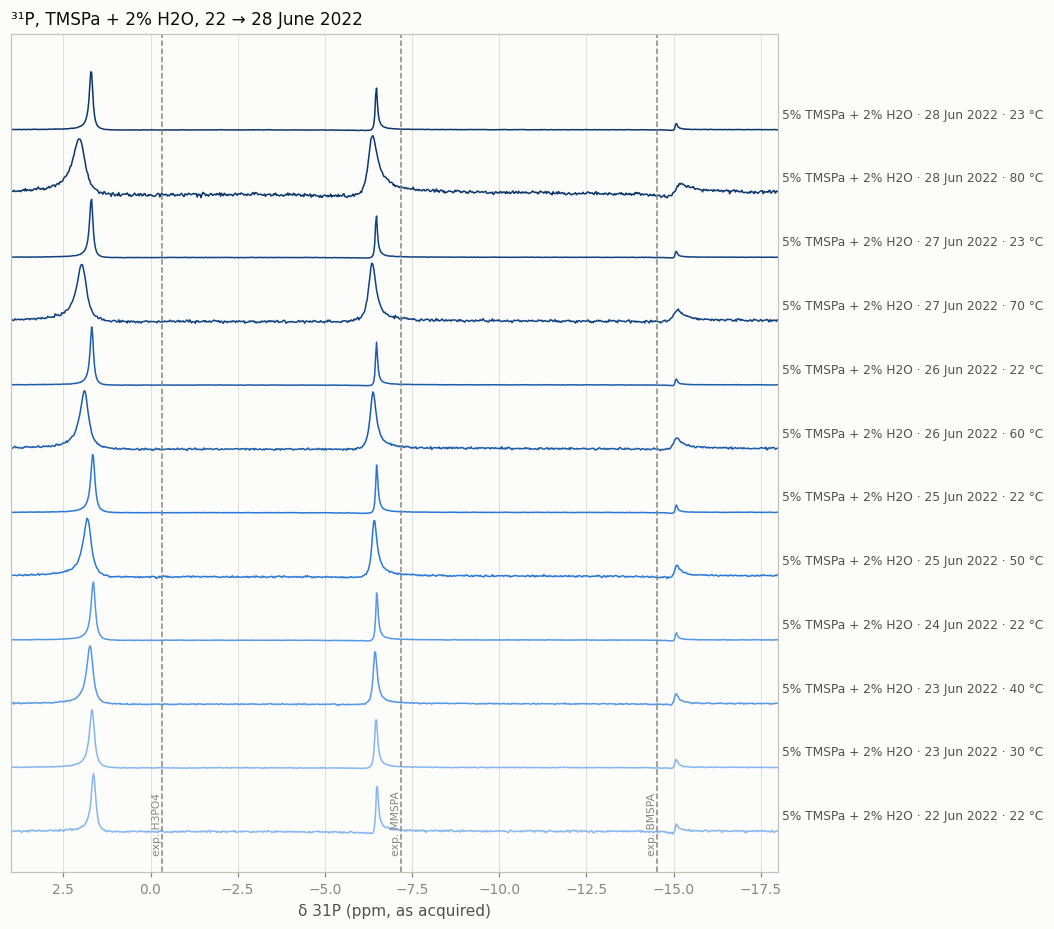

In [6]:
ramp = inventory[(inventory['sample'] == '5% TMSPa + 2% H2O') & (inventory['nucleus'] == '31P')].sort_values('acquired_at')
plot_spectra_stack([(label(r), *spectrum(r, (-18, 4))) for _, r in ramp.iterrows()], window_ppm=(-18, 4), nucleus='31P',
                   experimental=experimental, ordered=True, title='³¹P, TMSPa + 2% H2O, 22 → 28 June 2022')
plt.show()

Share of the ³¹P area in each of the three peaks, **room-temperature spectra only** (they share settings; the ones at temperature do not). The windows are set around the observed peaks.

,acquired_at,scans,BMSPA_fraction,MMSPA_fraction,H3PO4_fraction
0,2022-06-22 18:09:08,16,0.02,0.28,0.70
1,2022-06-24 03:09:41,256,0.04,0.30,0.66
2,2022-06-25 18:09:13,256,0.03,0.30,0.67
3,2022-06-26 18:09:29,256,0.03,0.30,0.67
4,2022-06-27 18:09:35,256,0.04,0.29,0.67
5,2022-06-28 19:10:11,256,0.04,0.30,0.66


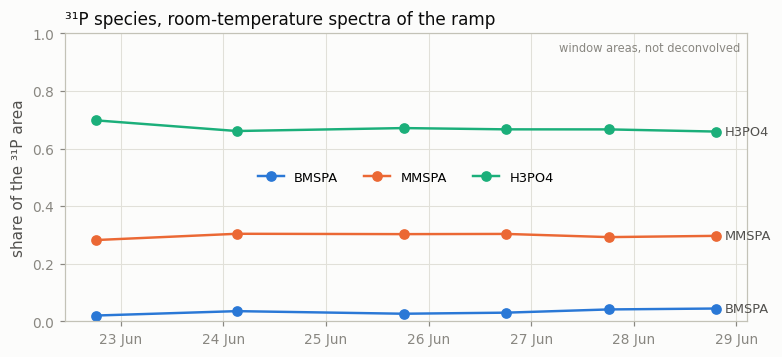

In [7]:
P_WINDOWS_PPM = {'BMSPA': (-16.5, -13.5), 'MMSPA': (-8.0, -5.0), 'H3PO4': (0.0, 3.5)}
rt = ramp[ramp['temperature_C'] < 25]
areas = pd.DataFrame([{'acquired_at': r['acquired_at'], 'scans': r['scans'],
                       **calculate_window_integrals(*spectrum(r, (-18, 4)), P_WINDOWS_PPM)} for _, r in rt.iterrows()])
total = areas[[f'{k}_area' for k in P_WINDOWS_PPM]].sum(axis=1)
for k in P_WINDOWS_PPM:
    areas[f'{k}_fraction'] = areas[f'{k}_area'] / total
shares = [f'{k}_fraction' for k in P_WINDOWS_PPM]
display(areas[['acquired_at', 'scans'] + shares].round({c: 2 for c in shares}))
fig = plot_peak_ratio_series(areas, x='acquired_at', ratios={f'{k}_fraction': k for k in P_WINDOWS_PPM},
                             ylabel='share of the ³¹P area', note='window areas, not deconvolved',
                             title='³¹P species, room-temperature spectra of the ramp')
plt.show()

**Reading.**
- The three shares stay flat: H₃PO₄ ≈ 0.66–0.70, MMSPA ≈ 0.28–0.30, BMSPA ≈ 0.02–0.04. TMSPA is already gone in the first spectrum. So heating from 30 to 80 °C did not change the composition, as in Gogoi 2024 (Fig. S2). The first spectrum has 16 scans and the rest 256, so it is noisier.
- At temperature the peaks broaden and H₃PO₄ moves from +1.6 to +2.1 ppm, but this is reversible: each room-temperature spectrum looks like the one before.
- If the water was already used up before the first spectrum (to check with the mixing time and the water content), this series only gives a lower bound on how fast hydrolysis is, not a rate.

### 4.2 TMSPa alone, fresh and after 10 days

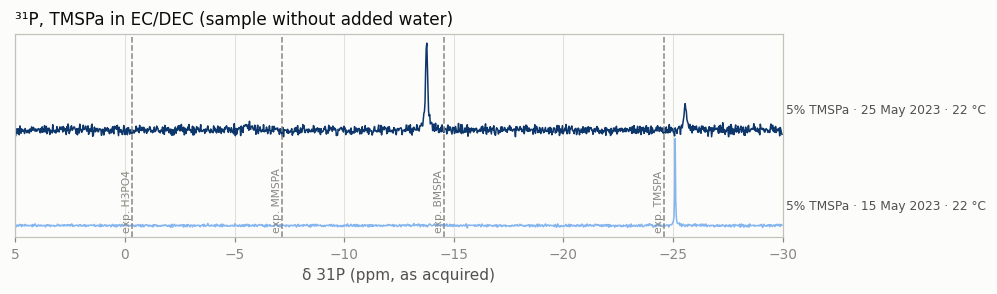

In [8]:
alone = inventory[(inventory['sample'] == '5% TMSPa') & (inventory['nucleus'] == '31P')].sort_values('acquired_at')
plot_spectra_stack([(label(r), *spectrum(r, (-30, 5))) for _, r in alone.iterrows()], window_ppm=(-30, 5),
                   nucleus='31P', experimental=experimental, ordered=True, title='³¹P, TMSPa in EC/DEC (sample without added water)')
plt.show()

**Reading.** On 15 May there is one peak, TMSPA. On 25 May it has become small and BMSPA (−13.8) dominates, although the sample is recorded without added water. Either the solvent already held water, or there is another route; the water content of the solvent decides which.

## 5. What is wrong or unclear in the files

Checked automatically from the headers: nucleus in the file name against the header, identical data stored under two names, lock solvent per sample, and the titles stored in the 2023 files.

In [9]:
print('Nucleus in the file name differs from the header:')
display(inventory.loc[inventory['nucleus'] != inventory['nucleus_in_name'], ['folder', 'file', 'nucleus', 'nucleus_in_name']])

print('Identical data under different file names:')
dup = inventory[inventory.duplicated('data_md5', keep=False)].sort_values('data_md5')
display(dup[['folder', 'file', 'acquired_at']])

print('Lock solvent per sample:')
display(inventory.groupby('sample')['lock_solvent'].unique())

print('Titles stored in each 2023 folder:')
display(inventory[inventory['campaign'] == 2023].groupby('folder')['title'].unique())

## 6. What we have

| | |
|---|---|
| Samples | 9: 4 in 2022, 5 in 2023 |
| Spectra | 89 `.jdf`, plus text exports |
| Best candidate for amounts | room-temperature ³¹P (NOE off) |
| What changes | TMSPa alone → BMSPA in 10 days (§4.2). Nothing changes during the 30 → 80 °C ramp (§4.1) |
| What does not exist yet | referenced axes, uncertainties on areas, a curated observables file |

**Next step, not in this notebook:** reference the axes, integrate with uncertainties, and build the observables file, before any fit of g.

The appendices hold the other nuclei (¹³C, ²⁹Si, ¹H), the check of the automatic processing, and the finer acquisition table.

## Appendix A · Check of the automatic processing

For TMSPa + 0.5% water, the processed spectra were also exported as text. Our transform of the same raw signals is overlaid on them: the peaks must fall at the same ppm. **This covers one sample only**; the rest are processed without an external reference.

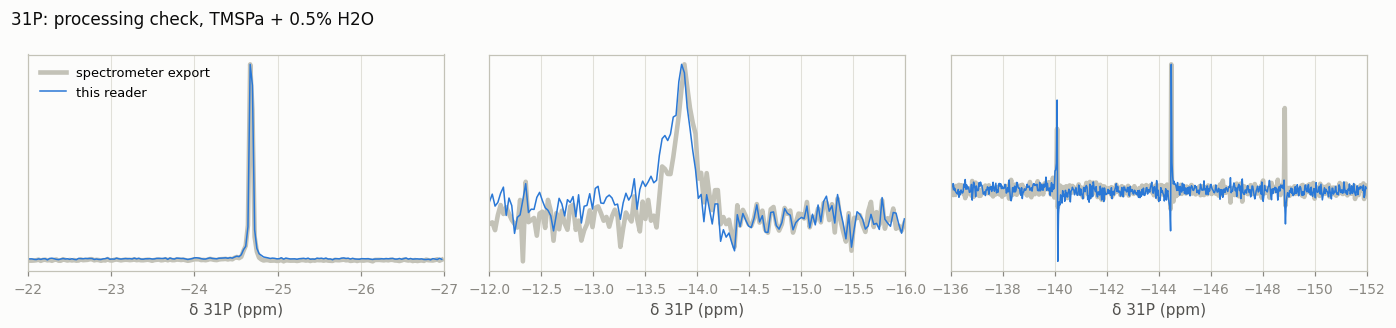

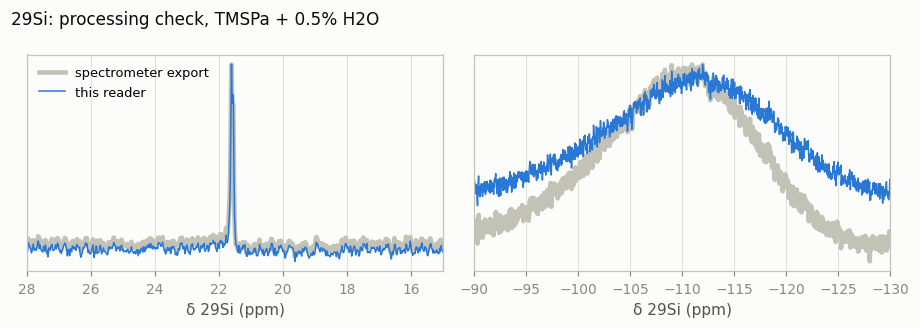

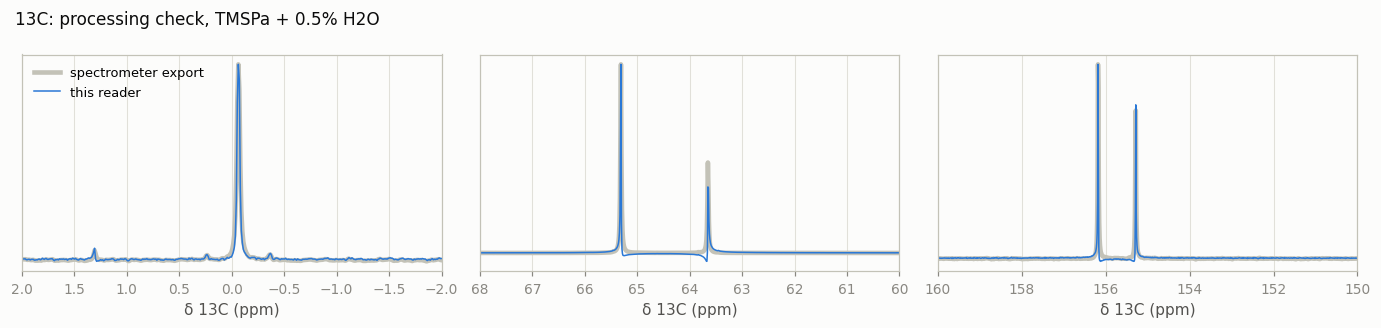

In [10]:
check = load_lab_sample_folders()['processing_check']
folder = DATA_DIR / check['folder']
for case in check['cases']:
    nucleus, windows = case['nucleus'], [tuple(w) for w in case['windows']]
    ours = [load_spectrum(folder / case['fid'], window_ppm=w) for w in windows]
    fig = plot_processing_check(ours, load_text_spectrum(folder / case['export']), windows_ppm=windows, nucleus=nucleus,
                                title=f'{nucleus}: processing check, TMSPa + 0.5% H2O')
    plt.show()

**Reading.** Peaks fall where the spectrometer's own export puts them. The broad ²⁹Si hump near −110 ppm is the glass of the tube and probe, not the sample. The narrow ³¹P lines at −140.1, −144.5 and −148.9 ppm appear in both traces and are 4.4 ppm apart, like PF₆⁻ (question 4).

## Appendix B · The other nuclei

### B.1 ¹³C, Si–CH₃ region of the TMSOH samples

TMSOH, TMSOTMS (HMDSO) and TMS-EG differ in the methyl carbons near 0 ppm (Gogoi 2024, Fig. 5a). One spectrum per stage.

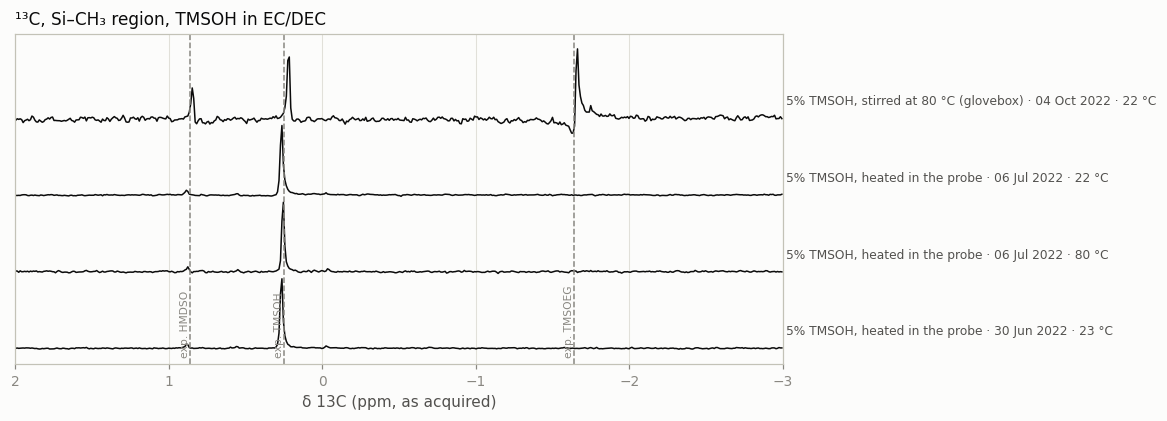

In [11]:
c13 = inventory[(inventory['nucleus'] == '13C') & inventory['sample'].str.startswith('5% TMSOH,')].sort_values('acquired_at')
plot_spectra_stack([(label(r), *spectrum(r, (-3, 2))) for _, r in c13.iterrows()], window_ppm=(-3, 2), nucleus='13C',
                   experimental=experimental, title='¹³C, Si–CH₃ region, TMSOH in EC/DEC')
plt.show()

**Reading.** Heated in the probe: TMSOH (+0.25) with a trace of HMDSO (+0.86), the same before, at 80 °C and after; no TMS-EG. Stirred at 80 °C in the glovebox: TMS-EG (−1.66) is clearly present, with TMSOH and HMDSO. Control E2 (TMS-EG after 8 h at 80 °C) rests on the second observation.

### B.2 ²⁹Si wherever there is signal

A spectrum is kept if its tallest peak in the window exceeds 8 times the noise at the spectral edge.

11 of 19 ²⁹Si spectra show signal above 8σ; without: 8


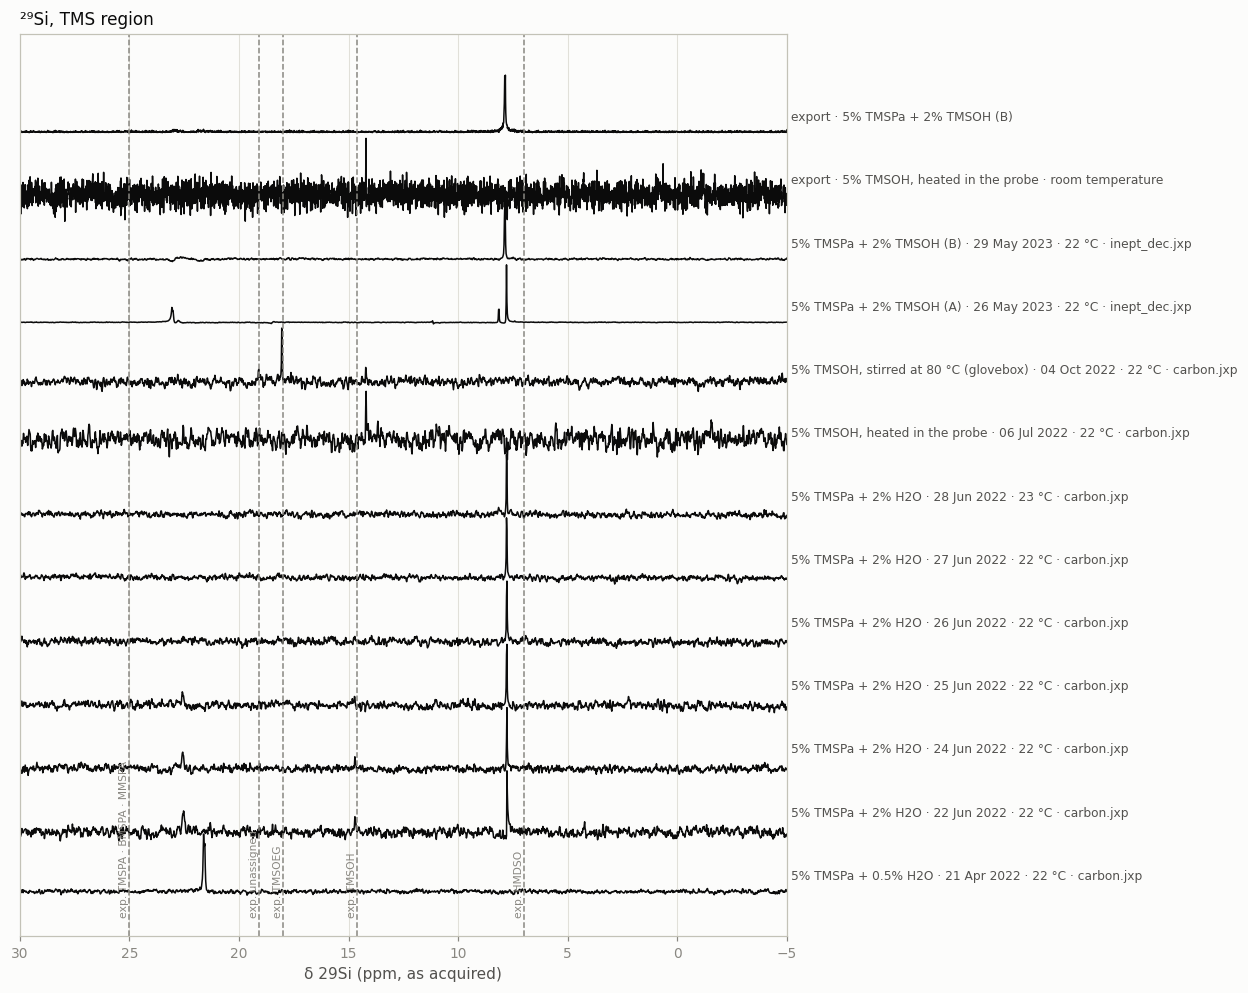

In [12]:
si = inventory[inventory['nucleus'] == '29Si'].drop_duplicates('data_md5').sort_values('acquired_at')
traces, empty = [], []
for _, r in si.iterrows():
    ppm, y = spectrum(r, (-5, 30))
    window = (ppm > -5) & (ppm < 30)
    (traces if y[window].max() > 8 * estimate_noise(y) else empty).append((label(r) + f" · {r['experiment']}", ppm, y))
for export in load_lab_sample_folders()['si_text_exports']:
    traces.append((export['label'], *load_text_spectrum(DATA_DIR / export['path'])))
print(f'{len(traces) - 2} of {len(si)} ²⁹Si spectra show signal above 8σ; without: {len(empty)}')
plot_spectra_stack(traces, window_ppm=(-5, 30), nucleus='29Si', experimental=experimental, title='²⁹Si, TMS region')
plt.show()

**Reading.** These show which Si species are present, not how much of each.
- **TMSPa + 2% water (2022):** the strongest line is at 7.8 ppm, in the HMDSO region, with weaker lines at 22.6 (silyl phosphates) and 14.7 (TMSOH). That fits released TMS groups condensing to HMDSO; amounts need a quantitative spectrum.
- **TMSPa + 0.5% water:** one line at 21.6 (TMSPA).
- **TMSOH stirred at 80 °C:** TMS-EG at 18.0 and the unassigned line near 19.1 reported by Gogoi, next to TMSOH (14.2). Heated in the probe: only TMSOH.
- Gogoi's "≈ 25 ppm" for silyl phosphates is approximate; ours fall at 21.6–23.0.

### B.3 ¹H, solvent and TMS regions

One spectrum per 2023 sample, first and last.

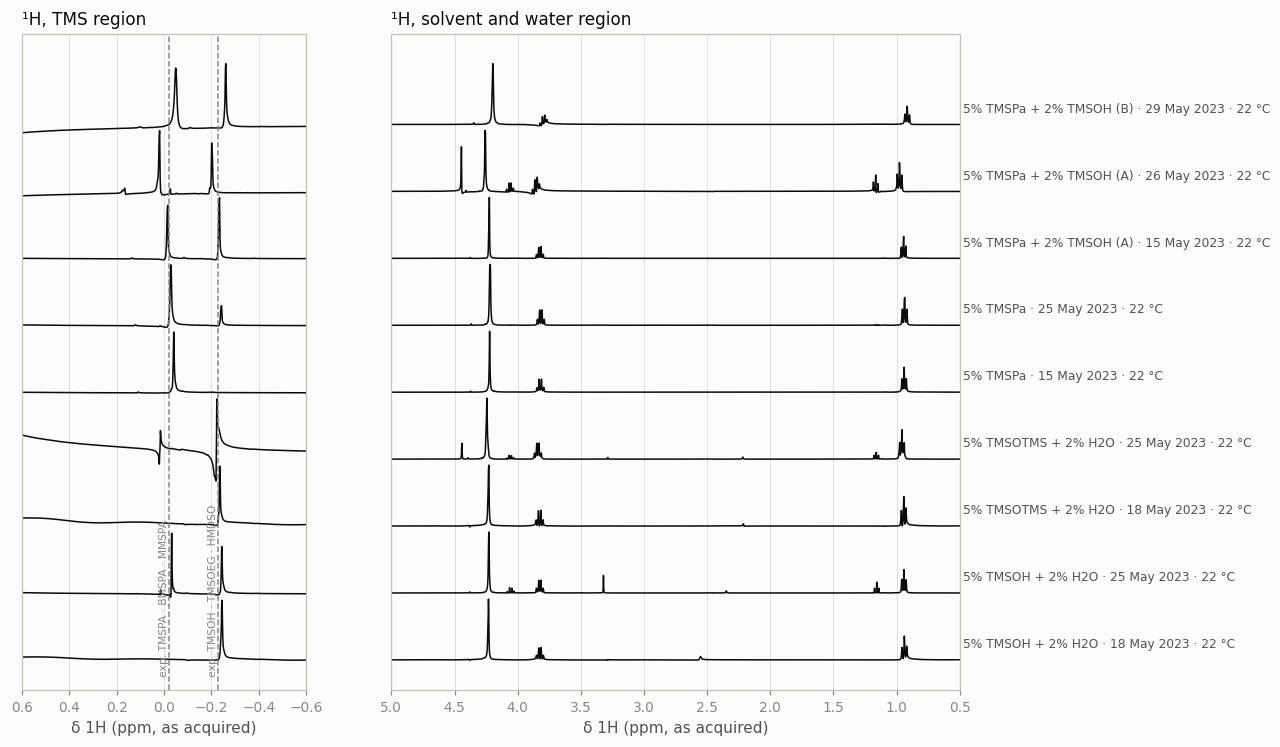

In [13]:
h1 = inventory[(inventory['nucleus'] == '1H') & (inventory['campaign'] == 2023)].drop_duplicates('data_md5')
h1 = pd.concat([h1.groupby('sample').head(1), h1.groupby('sample').tail(1)]).drop_duplicates('path').sort_values(['sample', 'acquired_at'])
fig, (ax_tms, ax_all) = plt.subplots(1, 2, figsize=(11, 1 + 0.75 * len(h1)), gridspec_kw={'width_ratios': [1, 2]})
plot_spectra_stack([('', *spectrum(r, (-0.6, 0.6))) for _, r in h1.iterrows()], window_ppm=(-0.6, 0.6),
                   nucleus='1H', experimental=experimental, ax=ax_tms, title='¹H, TMS region')
plot_spectra_stack([(label(r), *spectrum(r, (0.5, 5.0))) for _, r in h1.iterrows()], window_ppm=(0.5, 5.0),
                   nucleus='1H', ax=ax_all, title='¹H, solvent and water region')
plt.show()

**Reading.**
- **TMS region:** the TMSPa sample has one TMS line on 15 May and a second near −0.24 ppm on 25 May. TMSOH and TMSOTMS with water show two lines (≈ +0.0 and −0.23) that change between fresh and late. Which line is which species needs referencing and spiking.
- **Water:** its line moves between samples and days (2.55, 3.32, 2.21 ppm), as exchangeable OH does, so it cannot be integrated without assigning it.
- **New lines after 8–11 days:** a singlet at 4.44, a quartet at 4.05 and a triplet at 1.16 ppm appear in TMSOH + H2O, TMSOTMS + H2O and TMSPa + TMSOH (A), and not in the fresh spectra. Quartet + triplet is an ethyl group, so a DEC-derived product is possible. Unassigned.
- One spectrum (TMSOTMS + 2% H2O, 25 May) is still poorly phased in the TMS region.

## Appendix C · Acquisition settings in detail

In [14]:
settings = (inventory
            .groupby(['nucleus', 'experiment', 'scans', 'relaxation_delay_s', 'pulse_angle_deg', 'noe'], dropna=False)
            .agg(spectra=('file', 'size'), minutes_per_spectrum=('duration_min', 'median'),
                 at_temperature=('temperature_C', lambda t: int((t > 25).sum())))
            .reset_index())
display(settings.round({'minutes_per_spectrum': 1}))

,nucleus,experiment,scans,relaxation_delay_s,pulse_angle_deg,noe,spectra,minutes_per_spectrum,at_temperature
0,13C,carbon.jxp,50,2.0,30.0,TRUE,1,2.8,0
1,13C,carbon.jxp,64,2.0,30.0,TRUE,15,3.5,7
2,13C,carbon.jxp,256,2.0,30.0,TRUE,1,13.2,0
3,13C,carbon.jxp,1024,2.0,30.0,TRUE,1,52.2,0
4,19F,proton.jxp,16,5.0,45.0,NaN,1,1.8,0
5,1H,proton.jxp,16,1.0,45.0,NaN,2,0.9,0
6,1H,proton.jxp,16,4.0,45.0,NaN,2,1.8,0
7,1H,proton.jxp,16,5.0,45.0,NaN,7,2.1,0
8,1H,proton.jxp,50,1.0,45.0,NaN,1,2.7,0
9,1H,proton.jxp,64,1.0,45.0,NaN,15,3.5,7
